<a href="https://colab.research.google.com/github/2410072/Python-Lesson/blob/main/tree_shap_note.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# library
# basic
import pathlib as Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# learning model
import sklearn
import lightgbm
from sklearn.ensemble import RandomForestClassifier


# dataset
from sklearn.datasets import load_wine

# importance analysis
## SHAP
import shap
## Permutation Importance
from sklearn.inspection import permutation_importance

# other
from sklearn.metrics import accuracy_score, make_scorer
from sklearn.model_selection import train_test_split

In [ ]:
"""
input = Path(../directory)
output = Path(../directory_2)
"""

In [ ]:
# data load
wine = load_wine()
pd.DataFrame(wine.data, columns=wine.feature_names)

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
173,13.71,5.65,2.45,20.5,95.0,1.68,0.61,0.52,1.06,7.70,0.64,1.74,740.0
174,13.40,3.91,2.48,23.0,102.0,1.80,0.75,0.43,1.41,7.30,0.70,1.56,750.0
175,13.27,4.28,2.26,20.0,120.0,1.59,0.69,0.43,1.35,10.20,0.59,1.56,835.0
176,13.17,2.59,2.37,20.0,120.0,1.65,0.68,0.53,1.46,9.30,0.60,1.62,840.0


In [ ]:
X = wine.data
y = wine.target

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42)

In [ ]:
# train
lgbm = lightgbm.LGBMClassifier(random_state=42)
lgbm.fit(y=y_train, X=X_train, feature_name=wine.feature_names)

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000106 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 442
[LightGBM] [Info] Number of data points in the train set: 119, number of used features: 13
[LightGBM] [Info] Start training from score -1.115562
[LightGBM] [Info] Start training from score -0.928976
[LightGBM] [Info] Start training from score -1.282616
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No fur

LGBMClassifier(random_state=42)

In [ ]:
X = wine.data
y = wine.target

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42)

randomforest = RandomForestClassifier(random_state=42)
randomforest.fit(y=y_train, X=X_train)

accuracy_score_2(randomforest.predict(X_test), y_test)

explainer_2 = shap.TreeExplainer(randomforest)
shap_values_2 = explainer.shap_values(X_test)

In [ ]:
accuracy_score_3(lgbm.predict(X_test), y_test)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


0.9830508474576272

In [ ]:
# 可視化の準備
shap.initjs()

In [ ]:
# shap calculate
explainer = shap.TreeExplainer(lgbm)
shap_values = explainer.shap_values(X_test)

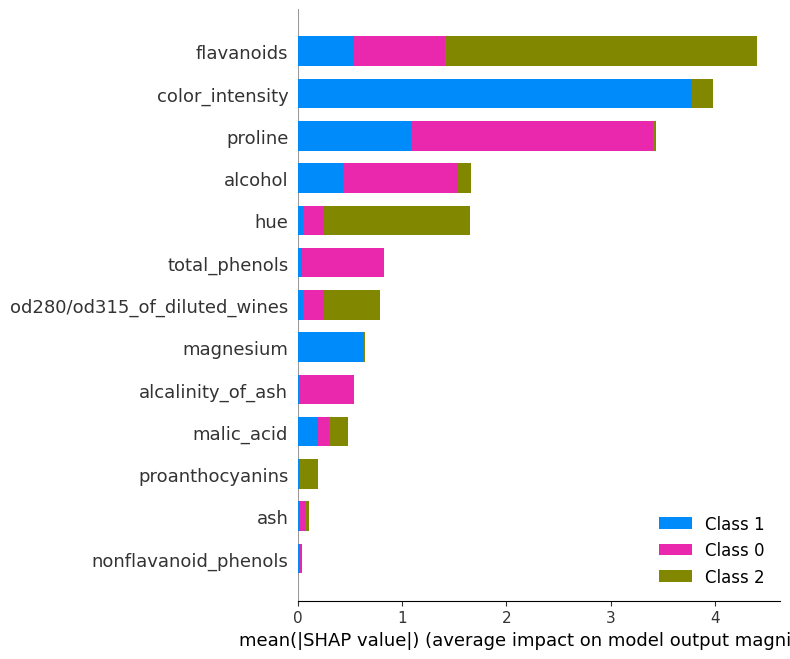

In [ ]:
# shap visu
shap.summary_plot(shap_values, plot_type='bar', feature_names=wine.feature_names)

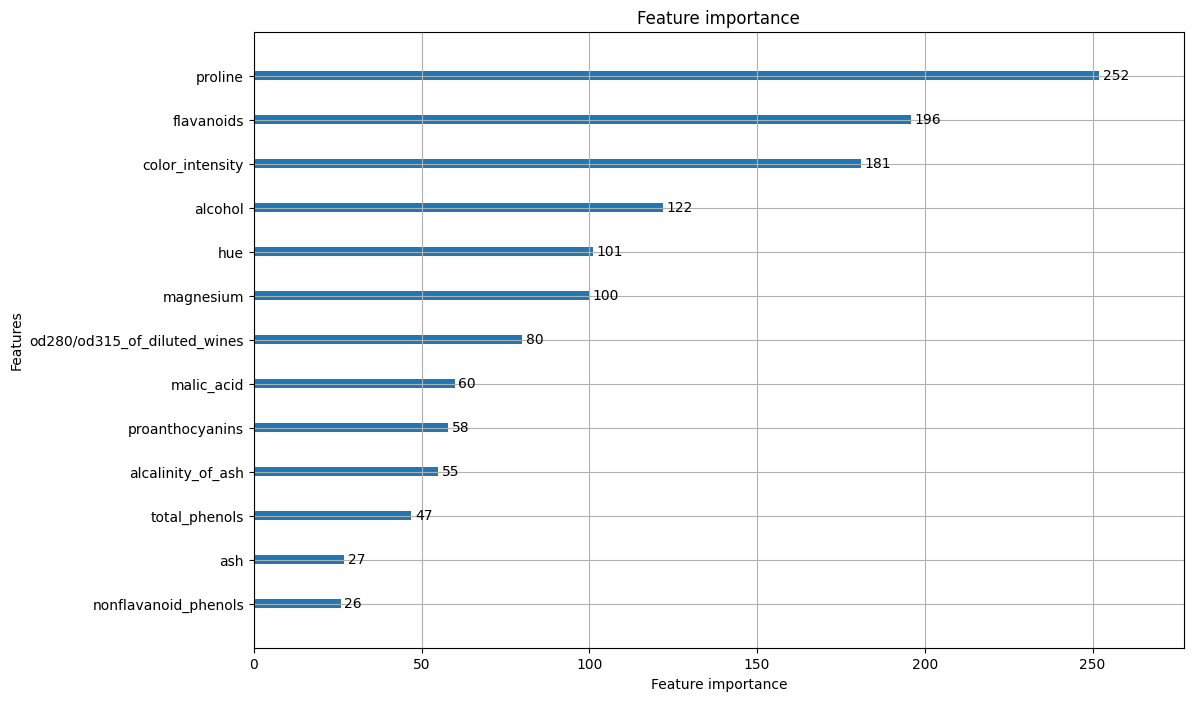

In [ ]:
# 分割に登場した回数をもとに特徴量重要度を算出
lightgbm.plot_importance(lgbm, importance_type="split", figsize=(12, 8))
plt.show()

In [ ]:
# rondomforest
X, y = make_classification(
    n_samples=1000,
    n_features=10,
    n_informative=3,
    n_redundant=2,
    n_classes=2,
    random_state=42
)